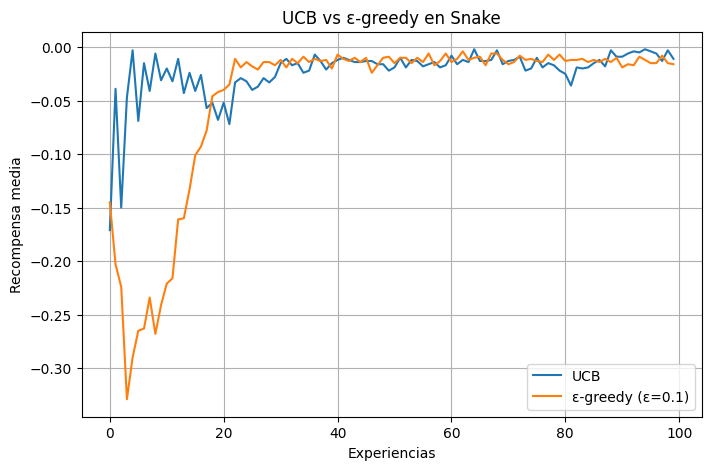

🍎 Total de manzanas comidas: 927
💥 Total de choques contra bordes: 7997


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

# ==============================
# 🧩 ENTORNO SNAKE
# ==============================
GRID_SIZE = 5
ACTIONS = {1: "up", 2: "down", 3: "left", 4: "right", 5: "stay"}

def init_positions():
    head = np.random.randint(0, GRID_SIZE, size=2)
    food = np.random.randint(0, GRID_SIZE, size=2)
    while np.array_equal(head, food):
        food = np.random.randint(0, GRID_SIZE, size=2)
    return head, food

def move(head, action):
    if action == "up": head = head + np.array([-1, 0])
    elif action == "down": head = head + np.array([1, 0])
    elif action == "left": head = head + np.array([0, -1])
    elif action == "right": head = head + np.array([0, 1])
    return head

def get_reward(head, food):
    if np.array_equal(head, food): return 1     # 🍎 Comer
    elif np.any(head < 0) or np.any(head >= GRID_SIZE): return -1  # 💥 Chocar
    else: return 0                             # Sin evento

# ==============================
# ⚙️ PARÁMETROS
# ==============================
partidas = 1000
turnos = 100
alpha = 0.5
c = 1
epsilons = [0.1, 0.1]
recompensas_medias = np.zeros((len(epsilons), turnos))
acciones_optimas = np.zeros((len(epsilons), turnos))

# 🔢 Contadores globales
total_comidas = 0
total_choques = 0

# ==============================
# 🔁 ENTRENAMIENTO
# ==============================
for ej in range(partidas):
    for i, e in enumerate(epsilons):
        Q = {k: 0 for k in range(1,6)}
        N = {k: 1 for k in range(1,6)}
        head, food = init_positions()
        mejor_accion = 1

        for exp in range(turnos):
            # --- Selección de acción ---
            if i == 0:  # 🔹 UCB
                maxA = -100
                for j in range(1, 6):
                    ucb_val = Q[j] + c * math.sqrt(math.log(exp + 1.1) / N[j])
                    if ucb_val > maxA:
                        maxA = ucb_val
                        a = j
            else:  # 🔸 ε-greedy
                if np.random.uniform(0, 1) < e:
                    a = np.random.randint(5) + 1
                else:
                    maxQ = -100
                    for j in range(1, 6):
                        if Q[j] > maxQ:
                            maxQ = Q[j]
                            a = j

            # --- Ejecutar acción ---
            new_head = move(head.copy(), ACTIONS[a])
            recompensa = get_reward(new_head, food)
            head = new_head
            N[a] += 1

            # --- Contadores de eventos ---
            if recompensa == 1:
                total_comidas += 1
            elif recompensa == -1:
                total_choques += 1

            # --- Actualización incremental ---
            Q[a] += alpha * (recompensa - Q[a])

            # --- Métricas ---
            recompensas_medias[i][exp] += recompensa
            acciones_optimas[i][exp] += (a == mejor_accion)

            # Reinicio si come o choca
            if recompensa != 0:
                head, food = init_positions()

# ==============================
# 📊 RESULTADOS
# ==============================
recompensas_medias /= partidas
acciones_optimas /= partidas

plt.figure(figsize=(8,5))
for i, e in enumerate(epsilons):
    label = "UCB" if i == 0 else f"ε-greedy (ε={e})"
    plt.plot(recompensas_medias[i], label=label)
plt.legend()
plt.grid(True)
plt.xlabel('Experiencias')
plt.ylabel('Recompensa media')
plt.title('UCB vs ε-greedy en Snake')
plt.show()

# ==============================
# 🧾 MOSTRAR CONTADORES
# ==============================
print("🍎 Total de manzanas comidas:", total_comidas)
print("💥 Total de choques contra bordes:", total_choques)
